# Introducción

Las llamadas LLM simples están limitadas por el conocimiento con el que se entrenó el modelo. Para solucionar esto, los desarrolladores usan cadenas o sistemas de agentes para otorgar a los LLM mayor control sobre los flujos de trabajo de la aplicación.

## ¿Por qué LangGraph?.

Dar más control a un LLM reduce la confiabilidad , pero LangGraph ayuda a mantener la confiabilidad al tiempo que permite un comportamiento agente .

• Más flexibilidad en el diseño de flujos de trabajo.

• Visibilidad clara del flujo de control (sin indicaciones complejas ocultas).

• Admite ciclos y persistencia , lo que lo hace adecuado para flujos de trabajo de IA iterativos

## Grafos en LangGraph

LangGraph estructura los flujos de trabajo como grafos  con nodos y bordes :

• **Nodos** : funciones de Python que definen la lógica del agente .

• **Bordes** : funciones de Python que deciden qué nodo se ejecuta a continuación en función del estado.

![](img/langGrapg.png)

## Workflow agéntico con LangGraph

Los flujos de trabajo agentísticos permiten a los LLM controlar el flujo de ejecución , adaptándose a la entrada, las condiciones y las herramientas del usuario . A diferencia de las cadenas fijas, los flujos de trabajo agentísticos toman decisiones en tiempo real , lo que mejora la flexibilidad y la automatización.

(estado)=
## Gestión de estados en LangGraph
```{index} TypeDict, Pydantic, messagesState, recucers, reductores
```

LangGraph utiliza un estado estructurado para mantener la coherencia de los datos del agente a medida que avanzan en un flujo de trabajo. Para un agente de atención al cliente, este estado puede incluir el historial de conversaciones, las preferencias del usuario, las decisiones de enrutamiento (departamento) y las tareas pendientes. A medida que los nodos procesan la información, el estado se actualiza y se transmite, lo que permite un comportamiento del agente modular y fácil de mantener.

Estos estados se consiguen mediante la creación de clases que heredan bien de **TypeDict**, de **Pydantic**, o de **messagesState**.

Dos opciones de esquema definen este estado:

• **TypedDict** para velocidad y simplicidad con tipos nativos de Python.

• **Pydantic**  para validación en tiempo de ejecución y modelos más enriquecidos, útil cuando se requiere integridad estricta de los datos.

Las actualizaciones de estado se controlan mediante reductores (reducers). De forma predeterminada, las actualizaciones sobrescriben los valores, pero los reductores permiten comportamientos personalizados, como la adición de listas. Cada campo del estado actúa como un canal independiente, de modo que los nodos pueden leer y escribir fragmentos específicos de forma independiente (p. ej., solo mensajes o solo departamento). LangGraph también admite patrones avanzados, como objetos de comando para actualizaciones complejas, bordes condicionales para el enrutamiento según el estado y persistencia/puntos de control para pausar, reanudar o depurar mediante viajes
en el tiempo.

## Códigos y ejemplos

Ejemplo de TypedDict para el estado de un agente:

```python
class AgentState(TypedDict):
    messages: list[str]
    user_preferences: dict
    department: str
    pending_tasks: list[str]
```

Ejemplo de reductor para agregar mensajes en lugar de sobrescribirlos:

```python
from typing import Annotated, TypedDict
from operator import add
class State(TypedDict):
    messages: Annotated[list[str], add] # Añade nuevos mensaje
    department: str # sobre escribe por defecto

```

*Notas*:

• Sin un reductor, las actualizaciones sobrescriben el valor existente.

• Con `Annotated` y `operator.add`, las actualizaciones de la lista se agregan a la lista existente.


## TypedDict vs Pydantic (cuándo elegir qué) 

• **TypedDict**

    – Ligero y nativo de Python

    – Alto rendimiento, sin validación en tiempo de ejecución

    – Acceso simple similar a un diccionario

    – Bueno para creación de prototipos y flujos sensibles al rendimiento

• **Pydantic**

    – Validación en tiempo de ejecución para la integridad de los datos

    – Admite estructuras y métodos complejos

    – Mejor para escenarios de producción que requieren una validación estricta

    – Rendimiento moderado debido a la sobrecarga de validación

## Ejemplo simple

Veamos en este ejemplo simple como podemos crear un flujo agéntico en langGraph

In [18]:
import random
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from IPython.display import Image, display
import asyncio

Definimos lo que es el estado del agente y para ello heredemos de TypeDict y declaramos dos estados de la agente: *input* y *output*. Observar que en este ejemplo no utilizamos reductores

In [19]:
class State(TypedDict):
    input: int
    output: int

A continuación definimos mediante simples funciones los nodos del agente

In [20]:
def node_a(state: State)->State:
    input_value = state['input']
    offset = random.randint(1,10)
    output = input_value + offset
    print(
    f"NODE A:\n"
    f"->input:{input_value}\n"
    f"->offset:{offset}\n"
    f"->output:{output}\n"
    )
    return State(output=output)


def node_b(state: State):
    input_value = state['input']
    offset = random.randint(1,10)
    output = input_value + offset
    print(
    f"NODE B:\n"
    f"->input:{input_value}\n"
    f"->offset:{offset}\n"
    f"->output:{output}\n"
    )
    return {"output":output} 



Definidos los nodos, los unimos de la siguiente manera

In [21]:
workflow = StateGraph(state_schema=State)
# añadimos los nodos
workflow.add_node(node_a)
workflow.add_node(node_b)

In [22]:
#agregamos tres aristas (edges)
workflow.add_edge(START,"node_a")
workflow.add_edge("node_a","node_b")

Compilamos el grafo que antes hemos definido

In [23]:
# compilamos el grafo
graph = workflow.compile()

Y finalmente mostramos el grafo mediante una imagen

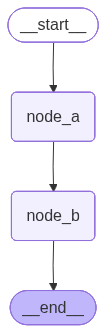

In [24]:
# Dibujamos el grafo
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

Ya estamos en condiciones de ejecutar ese grafo

In [25]:
# Finalmente ejecutamos
graph.invoke(
    input = {
        "input":1
    }
)

NODE A:
->input:1
->offset:2
->output:3

NODE B:
->input:1
->offset:6
->output:7



{'input': 1, 'output': 7}

## Versión asíncrona del ejemplo

Mostramos a continuación cómo conseguimos la versión asíncrona del ejemplo anterior

In [26]:
async def node_a2(state: State)->State:
    input_value = state['input']
    offset = random.randint(1,10)
    output = input_value + offset
    print(
    f"NODE A:\n"
    f"->input:{input_value}\n"
    f"->offset:{offset}\n"
    f"->output:{output}\n"
    )
    return State(output=output)


async def node_b2(state: State):
    input_value = state['input']
    offset = random.randint(1,10)
    output = input_value + offset
    print(
    f"NODE B:\n"
    f"->input:{input_value}\n"
    f"->offset:{offset}\n"
    f"->output:{output}\n"
    )
    return {"output":output} 


In [27]:
workflow = StateGraph(state_schema=State)
# añadimos los nodos
workflow.add_node(node_a2)
workflow.add_node(node_b2)

#agregamos tres aristas (edges)
workflow.add_edge(START,"node_a2")
workflow.add_edge("node_a2","node_b2")

# compilamos el grafo
graph = workflow.compile()

In [28]:
async def ejecutar():
    await graph.ainvoke(  ## ****Observar el uso de ainvoke que sustituye a invoke
    input = {
        "input":1
    }
)
    


In [29]:
asyncio.run(ejecutar())

NODE A:
->input:1
->offset:7
->output:8

NODE B:
->input:1
->offset:2
->output:3



Este error es muy típico en Jupyter, y **no es que hayas hecho algo “mal”**, sino que el entorno ya tiene un event loop de asyncio corriendo. Lo que ocurre es que `asyncio.run()` intenta crear y ejecutar su propio loop, pero Jupyter (a través de IPython) ya tiene uno activo, así que choca.

Para resolver est utilizamos la librería `nest_asyncio`
```{index} nest_asyncio
```

In [30]:
import nest_asyncio
nest_asyncio.apply()

asyncio.run(ejecutar())

NODE A:
->input:1
->offset:7
->output:8

NODE B:
->input:1
->offset:5
->output:6



## Ejercicio: Estado del servicio de atención al cliente

Esta demostración aplica un flujo de trabajo con estado usando LangGraph para dirigir los mensajes de los clientes a facturación, técnicos o ventas, resolver el problema y registrar su seguimiento. El flujo utiliza un estado tipificado, reductores para la acumulación de mensajes e historial, un nodo enrutador, controladores de departamento y un puntero de control para mantener la continuidad entre turnos.

In [32]:
from typing import TypedDict, List, Optional, Literal, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
import operator
import uuid

1.- Definir el estado y los reductores

• Cree un TypedDict con campos para mensajes, departamento, user_id, issue_id, user_name,
issue_history y resuelto.

• Utilice *add_messages* para fusionar mensajes entre nodos.

• Utilice el operador *.add* para agregar al issue_history en los pasos.

In [33]:
class CustomerServiceState(TypedDict):
    messages: Annotated[list, add_messages]
    department: Optional[Literal["billing", "technical", "sales"]]
    user_id: str
    issue_id: Optional[str]
    user_name: Optional[str]
    issue_history: Annotated[List[str], operator.add]
    resolved: bool

Implementar el nodo enrutador

* Lea el último mensaje del usuario.

* Hacer coincidir palabras clave con un departamento.

* Emite un AIMessage inicial y crea un UUID issue_id.

* Establezca solved=False para continuar el flujo.

A continuación definimos las funciones que vana definir los nodos del grafo

In [35]:
from langchain_core.messages import HumanMessage, AIMessage
import uuid

# función de enrutamiento determine department based on keywords and adds␣inicitial task
# Determinar el departamento en función de las palabras clave y añadir la tarea␣inicial.

def route_customer(state: CustomerServiceState) -> CustomerServiceState:
    department = None
    ai_message = None
    if not state["messages"]:
    # si no hay mensage incial se devuelve el estado tal y como está
        return state
    # en caso contrario, se devuelve el último mensaje
    last_message = state["messages"][-1].content.lower()
    # si el último mensaje contiene alguna de la palabras "bill", "payment",   "charge"
    # se asigna el departamento de billing
    if any(word in last_message for word in ["bill", "payment", "charge"]):
        department = "billing"
        # Se añade un mensaje de tipo AImessage
        ai_message = AIMessage(content="I'll help you with your billing issue.␣ Let me check your account.")
    # si contiene alguna de las palabras "broken", "error", "not working"
    # se asigna al departamento technical
    elif any(word in last_message for word in ["broken", "error", "not␣ working"]):
        department = "technical"
        # Let's troubleshoot your technical issue. == Vamos a solucionar tu␣problema técnico.
        ai_message = AIMessage(content="Let's troubleshoot your technical issue.")
    elif any(word in last_message for word in ["buy", "purchase", "upgrade"]):
        department = "sales"
        ai_message = AIMessage(content="I'd be happy to help with your purchase.")
    return {"messages": [ai_message], "department": department, "issue_id": str(uuid.uuid4()), "resolved": False}
    # str(uuid.uuid4()) == Genera un UUID (identificador único universal)␣aleatorio versión 4
    # y conviértelo a una cadena de texto.
    # uuid.uuid4() crea un UUID v4, que es un identificador aleatorio de 128␣bits
    # (por ejemplo: e3c9b2a4-4f0b-4c8a-8cd2-2b7a3d1e9cbb).

In [36]:
# Los gestores del departamento procesan y resuelven los problemas.
def handle_billing(state: CustomerServiceState) -> CustomerServiceState:
    new_issues_id = "billing-" + state["issue_id"]
    return {"messages": [AIMessage(content="Retrieved billing history: Last␣ payment $99")],
    "resolved": True, "issue_history": [new_issues_id]}

def handle_technical(state: CustomerServiceState) -> CustomerServiceState:
    new_issues_id = "technical-" + state["issue_id"]
    return {"messages": [AIMessage(content="Diagnostics complete. No hardware␣issues detected.")],
    "resolved": True, "issue_history": [new_issues_id]}

def handle_sales(state: CustomerServiceState) -> CustomerServiceState:
    new_issues_id = "sales-" + state["issue_id"]
    return {"messages": [AIMessage(content="Products available: Premium␣Upgrade, Family Plan.")],
        "resolved": True, "issue_history": [new_issues_id]}

La función que se define posteriormente llamada `next_step` va a servir para dirigir el flujo del grafo hacia un nodo u otro

In [38]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

workflow = StateGraph(CustomerServiceState)

# nodo del enrutador
workflow.add_node("router", route_customer)

def next_step(state: CustomerServiceState):
    if state["resolved"]:
        return END
    return state["department"] or "router"

workflow.add_node("billing", handle_billing)
workflow.add_node("technical", handle_technical)
workflow.add_node("sales", handle_sales)
# definimos la entrada al flujo de trabajo
workflow.set_entry_point("router")

workflow.add_conditional_edges("router", next_step)
workflow.add_edge("billing", END)
workflow.add_edge("technical", END)
workflow.add_edge("sales", END)

# esto lo hacemos para mantener la memoria a corto plazo del agente
memory = InMemorySaver()
app = workflow.compile(checkpointer=memory)

In [39]:
config = {"configurable": {"thread_id": "user123"}}

state1 = CustomerServiceState(
    messages=[HumanMessage(content="My bill seems too high this month")],
    department=None,
    user_id="user123",
    user_name="John Doe",
    issue_history=[],
    resolved=False
)
result1 = app.invoke(state1, config=config)
print("Department:", result1['department'])
print("Final response:", result1['messages'][-1].content)
print("Customer issue history:", result1['issue_history'])

Department: billing
Final response: Retrieved billing history: Last␣ payment $99
Customer issue history: ['billing-8a36d389-8d8f-4145-9e9e-07db6161128c']


In [40]:
config = {"configurable": {"thread_id": "user123"}}
state1 = CustomerServiceState(
messages=[HumanMessage(content="My bill seems too high this month")],
department=None,
user_id="user123",
user_name="John Doe",
issue_history=[],
resolved=False
)
result1 = app.invoke(state1, config=config)
print("Department:", result1['department'])
print("Final response:", result1['messages'][-1].content)
print("Customer issue history:", result1['issue_history'])

Department: billing
Final response: Retrieved billing history: Last␣ payment $99
Customer issue history: ['billing-8a36d389-8d8f-4145-9e9e-07db6161128c', 'billing-3c358199-d402-408c-b6df-3266263463ca']
